### Lab 8: Decision Trees
8.3.1 Fitting Classification Trees

BASE TREE PERFORMANCE
Number of terminal nodes: 33
Test Accuracy (Unpruned): 0.7350

CROSS-VALIDATION RESULTS
Best ccp_alpha found: 0.000000

PRUNED TREE PERFORMANCE
Number of terminal nodes: 33
Test Accuracy (Pruned)  : 0.7350

Confusion Matrix:
          Pred No  Pred Yes
True No        94        32
True Yes       21        53


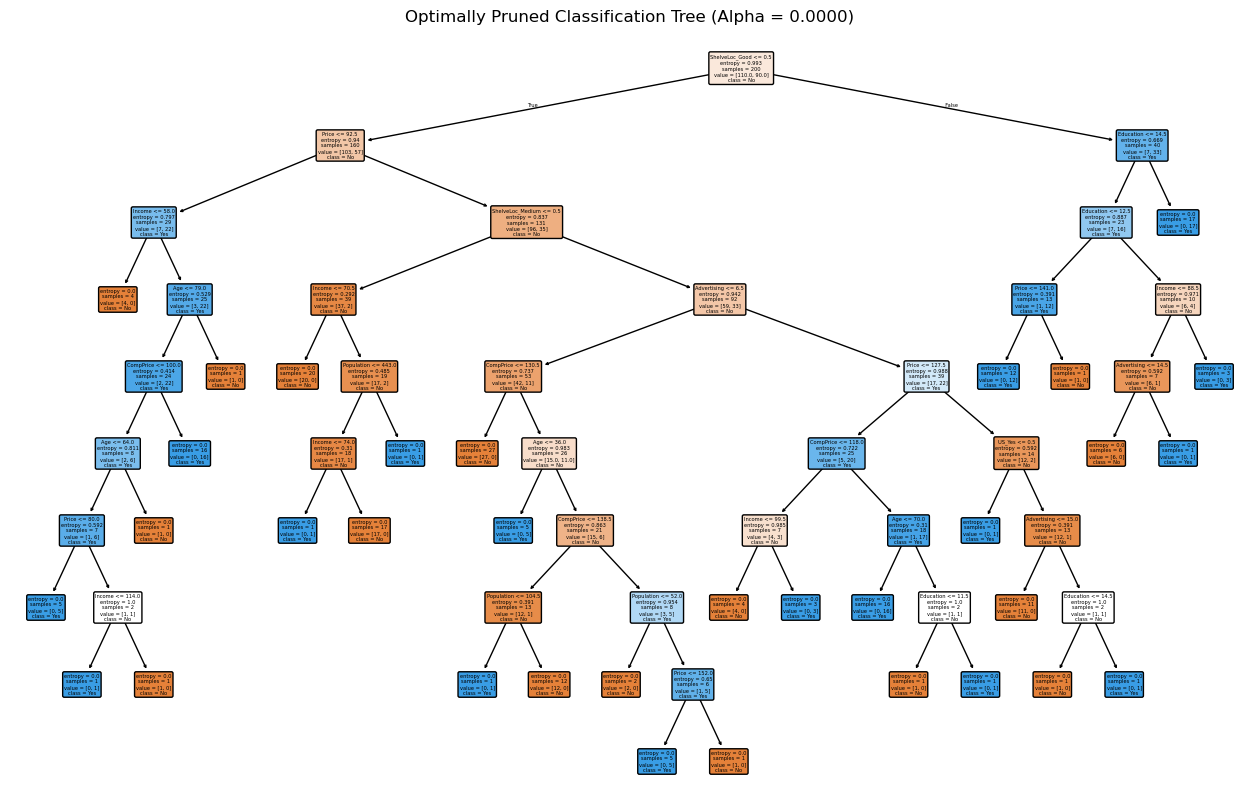

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
import statsmodels.api as sm
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score


# 1. Load data
carseats = pd.read_csv("data/Carseats.csv")

# Создаем бинарный целевой признак High (Sales > 8)
carseats["High"] = np.where(carseats["Sales"] > 8, "Yes", "No")

# Remove Sales variable
X = carseats.drop(columns=["Sales", "High"])
y = carseats["High"]

# Coding categorical features (ShelveLoc, Urban, US) One-Hot Encoding
X = pd.get_dummies(X, columns=["ShelveLoc", "Urban", "US"], drop_first=True)

# 2. Dividing train test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=200, random_state=2)

# 3. Fit base model
base_tree = DecisionTreeClassifier(criterion="entropy", random_state=42)
base_tree.fit(X_train, y_train)

# Estimating base model
y_pred_base = base_tree.predict(X_test)
base_acc = accuracy_score(y_test, y_pred_base)
print("BASE TREE PERFORMANCE")
print(f"Number of terminal nodes: {base_tree.get_n_leaves()}")
print(f"Test Accuracy (Unpruned): {base_acc:.4f}\n")

# 4. Pruning (Cost Complexity Pruning)
path = base_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

# Selecting best ccp_alpha
kf = KFold(n_splits=5, shuffle=True, random_state=3)
alpha_scores = []

for alpha in ccp_alphas:
    fold_accuracies = []
    for train_idx, val_idx in kf.split(X_train):
        clf = DecisionTreeClassifier(criterion="entropy", ccp_alpha=alpha, random_state=42)
        clf.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        
        val_pred = clf.predict(X_train.iloc[val_idx])
        fold_accuracies.append(accuracy_score(y_train.iloc[val_idx], val_pred))
        
    alpha_scores.append(np.mean(fold_accuracies))

best_alpha = ccp_alphas[np.argmax(alpha_scores)]
print("CROSS-VALIDATION RESULTS")
print(f"Best ccp_alpha found: {best_alpha:.6f}")

# 5. Final pruning using best alpha
pruned_tree = DecisionTreeClassifier(criterion="entropy", ccp_alpha=best_alpha, random_state=42)
pruned_tree.fit(X_train, y_train)

# Estimating the model
y_pred_pruned = pruned_tree.predict(X_test)
pruned_acc = accuracy_score(y_test, y_pred_pruned)

print("\nPRUNED TREE PERFORMANCE")
print(f"Number of terminal nodes: {pruned_tree.get_n_leaves()}")
print(f"Test Accuracy (Pruned)  : {pruned_acc:.4f}")
print("\nConfusion Matrix:")
print(pd.DataFrame(confusion_matrix(y_test, y_pred_pruned), 
                   index=["True No", "True Yes"], 
                   columns=["Pred No", "Pred Yes"]))

plt.figure(figsize=(16, 10))
plot_tree(pruned_tree, feature_names=X.columns, class_names=["No", "Yes"], filled=True, rounded=True)
plt.title(f"Optimally Pruned Classification Tree (Alpha = {best_alpha:.4f})")
plt.show()

Interestingly, the 5-fold cross-validation procedure selected an optimal complexity parameter of ccp_alpha = 0.000000. Consequently, the pruning algorithm did not eliminate any branches, leaving the final tree identical to the initial unpruned model with 33 terminal nodes and a test accuracy of 73.50%. This indicates that on this specific split of the training data, the added complexity of the deeper subtrees was justified by a genuine reduction in empirical risk during cross-validation, meaning no complexity penalty was enforced

Analyzing the test set performance via the confusion matrix yields a Recall of 71.62% ($53/74$) and a Precision of 62.35% ($53/85$). These results present a trade-off in model behavior:
- High Recall (71.62%) demonstrates that the model is quite aggressive and effective at identifying high-performing stores, successfully capturing nearly 72% of the true positive instances.
- Lower Precision (62.35%) reveals that this boldness comes at a cost; the model suffers from a relatively high false-positive rate (32 instances), frequently misclassifying low-performing locations as high-performing ones